# ECG Heartbeat Classification Project
## Phase 4 — Machine Learning Model Training

This notebook loads the extracted feature dataset from Phase 3
and trains machine learning models to classify heartbeats as
Normal or Abnormal. Two classifiers are trained and compared —
Random Forest and Support Vector Machine. Models are evaluated
using accuracy, precision, recall and F1-score to handle the
class imbalance in the dataset.

### Import libraries and load feature dataset
Loading the feature table saved in Phase 3 containing 102,382
heartbeat segments with 13 extracted features each.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Load the feature dataset saved in Phase 3
df = pd.read_csv('../data/ecg_features.csv')

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"Rows (beats):    {df.shape[0]:,}")
print(f"Columns:         {df.shape[1]}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nClass distribution:")
print(f"  Normal   (0): {(df['label']==0).sum():,} beats ({(df['label']==0).sum()/len(df)*100:.1f}%)")
print(f"  Abnormal (1): {(df['label']==1).sum():,} beats ({(df['label']==1).sum()/len(df)*100:.1f}%)")

Dataset loaded successfully!

Shape: (102382, 14)
Rows (beats):    102,382
Columns:         14

First 5 rows:
       mean       std    max    min  range  r_peak_amplitude  skewness  \
0 -0.309792  0.169131  0.940 -0.535  1.475             0.940  5.099975   
1 -0.332389  0.153550  0.960 -0.570  1.530             0.885  5.974568   
2 -0.332958  0.145797  0.860 -0.645  1.505             0.810  5.654252   
3 -0.331958  0.138210  0.820 -0.565  1.385             0.820  5.651994   
4 -0.325750  0.146924  0.885 -0.545  1.430             0.885  5.526280   

    kurtosis  qrs_width  rr_interval  mean_first_half  mean_second_half  \
0  30.913988   0.019444     0.811111        -0.273333         -0.346250   
1  41.714788   0.016667     0.788889        -0.315139         -0.349639   
2  39.148715   0.016667     0.791667        -0.335917         -0.330000   
3  39.482946   0.013889     0.788889        -0.309944         -0.353972   
4  37.605972   0.016667     0.816667        -0.304556         -0.34694

### Splitting data into training and testing sets
The dataset is split 80/20 into training and testing sets.
The model learns from the training set and is evaluated on
the testing set which it has never seen before — proving
genuine learning rather than memorisation.

In [2]:
# Separate features (X) from labels (y)
# X contains all 13 feature columns
# y contains just the label column (0=Normal, 1=Abnormal)
X = df.drop('label', axis=1)
y = df['label']

print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape:   {y.shape}")
print(f"Feature names: {list(X.columns)}")

# Split into 80% training and 20% testing
# random_state=42 ensures we get the same split every time we run
# stratify=y ensures both sets have the same class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  Normal beats:   {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Abnormal beats: {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")

print(f"\nTesting set:")
print(f"  X_test shape:  {X_test.shape}")
print(f"  Normal beats:   {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"  Abnormal beats: {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")

# Scale the features — important for SVM
# StandardScaler converts all features to same scale (mean=0, std=1)
# This prevents features with large values dominating smaller ones
scaler = StandardScaler()

# Fit scaler on training data only — never on test data
# This prevents data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nFeature scaling complete!")
print(f"  Training mean after scaling: {X_train_scaled.mean():.4f} (should be ~0)")
print(f"  Training std after scaling:  {X_train_scaled.std():.4f} (should be ~1)")

Features (X) shape: (102382, 13)
Labels (y) shape:   (102382,)
Feature names: ['mean', 'std', 'max', 'min', 'range', 'r_peak_amplitude', 'skewness', 'kurtosis', 'qrs_width', 'rr_interval', 'mean_first_half', 'mean_second_half', 'half_difference']

Training set:
  X_train shape: (81905, 13)
  Normal beats:   60,008 (73.3%)
  Abnormal beats: 21,897 (26.7%)

Testing set:
  X_test shape:  (20477, 13)
  Normal beats:   15,003 (73.3%)
  Abnormal beats: 5,474 (26.7%)

Feature scaling complete!
  Training mean after scaling: -0.0000 (should be ~0)
  Training std after scaling:  1.0000 (should be ~1)


### Training Random Forest Classifier
Random Forest builds hundreds of decision trees on random subsets
of the training data and combines their predictions by majority
voting. class_weight='balanced' automatically compensates for the
73/27 class imbalance by giving more importance to Abnormal beats
during training.

In [4]:
print("Training Random Forest classifier...")

# Create Random Forest with 100 trees
# class_weight='balanced' handles the 73/27 class imbalance
# random_state=42 ensures reproducible results
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees in the forest
    class_weight='balanced', # handle class imbalance
    random_state=42,         # reproducibility
    n_jobs=-1                # use all CPU cores for faster training
)

# Train the model on training data
# The model looks at 81,905 beats and learns the patterns
rf_model.fit(X_train, y_train)

print("Training complete!")

# Make predictions on the test set
# The model has never seen these 20,477 beats before
rf_predictions = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_accuracy  = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall    = recall_score(y_test, rf_predictions)
rf_f1        = f1_score(y_test, rf_predictions)

print(f"\nRandom Forest Results:")
print(f"{'─'*40}")
print(f"  Accuracy:  {rf_accuracy*100:.2f}%")
print(f"  Precision: {rf_precision*100:.2f}%")
print(f"  Recall:    {rf_recall*100:.2f}%")
print(f"  F1 Score:  {rf_f1*100:.2f}%")

# Full classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, rf_predictions,
      target_names=['Normal', 'Abnormal']))

Training Random Forest classifier...
Training complete!

Random Forest Results:
────────────────────────────────────────
  Accuracy:  97.26%
  Precision: 97.52%
  Recall:    92.07%
  F1 Score:  94.72%

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98     15003
    Abnormal       0.98      0.92      0.95      5474

    accuracy                           0.97     20477
   macro avg       0.97      0.96      0.96     20477
weighted avg       0.97      0.97      0.97     20477



### Random Forest results

The Random Forest classifier achieved strong performance on the
test set of 20,477 unseen heartbeats:

- Accuracy of 97.26% — correctly classified the vast majority
- Precision of 97.52% — very few false abnormal predictions
- Recall of 92.07% — catches 92% of all abnormal beats
- F1 Score of 94.72% — strong balance between precision and recall

Normal beats show near perfect recall (0.99) while Abnormal beats
show slightly lower recall (0.92) — consistent with the EDA finding
that Atrial Premature beats are visually similar to Normal beats
making them harder to classify correctly.

### Confusion Matrix
The confusion matrix shows exactly where the model makes correct
and incorrect predictions. False Negatives (predicting Normal when
actually Abnormal) are the most clinically dangerous errors as they
represent missed abnormal heartbeats.

Confusion Matrix Results:
  True Negatives  (correct Normal):    14,875
  True Positives  (correct Abnormal):  5,040
  False Positives (wrong Abnormal):    128
  False Negatives (missed Abnormal):   434

Most critical — missed abnormal beats: 434
That is 7.9% of all abnormal beats missed


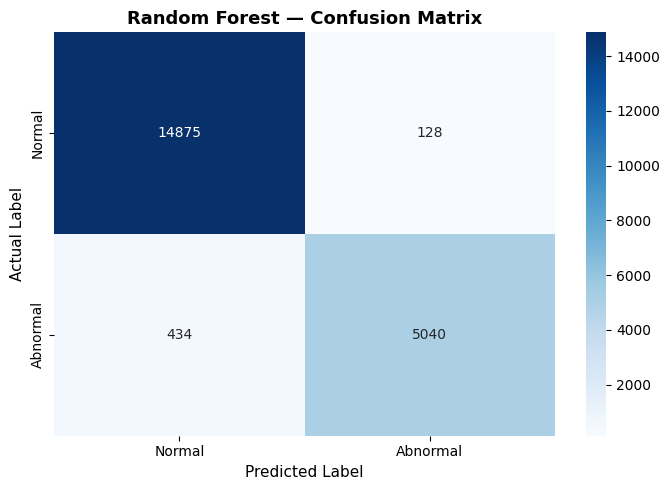

In [5]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

# Extract individual values
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Results:")
print(f"  True Negatives  (correct Normal):    {tn:,}")
print(f"  True Positives  (correct Abnormal):  {tp:,}")
print(f"  False Positives (wrong Abnormal):    {fp:,}")
print(f"  False Negatives (missed Abnormal):   {fn:,}")
print(f"\nMost critical — missed abnormal beats: {fn:,}")
print(f"That is {fn/5474*100:.1f}% of all abnormal beats missed")

# Plot confusion matrix as heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'],
            ax=ax)

ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

### Confusion Matrix observations

- 14,875 Normal beats correctly identified (99.1% of all Normal)
- 5,040 Abnormal beats correctly identified (92.1% of all Abnormal)
- 128 False Positives — Normal beats incorrectly flagged as Abnormal
- 434 False Negatives — Abnormal beats missed (7.9% miss rate)

The False Negative rate of 7.9% represents the most clinically
significant limitation — these are real abnormal heartbeats that
the model failed to detect. Most of these are likely Atrial
Premature beats which are visually similar to Normal beats as
identified during EDA in Phase 3.

The False Positive rate is very low at 128 cases (0.85% of Normal
beats) meaning the model rarely raises false alarms.

### Training Support Vector Machine Classifier
SVM finds the optimal boundary between Normal and Abnormal beats
in the feature space. It uses scaled features and class weights
to handle the class imbalance. SVM provides a different mathematical
approach to Random Forest allowing meaningful comparison between
the two models.

In [9]:
print("Training SVM classifier:")


# Create SVM with RBF kernel
# RBF kernel handles non-linear boundaries between classes
# class_weight='balanced' handles the 73/27 class imbalance
# C=1.0 controls the trade-off between correct classification
# and smooth decision boundary
svm_model = SVC(
    kernel='rbf',            # radial basis function kernel
    class_weight='balanced', # handle class imbalance
    random_state=42,         # reproducibility
    C=1.0,                   # regularisation parameter
    probability=False        # faster training without probabilities
)

# Train on scaled features — SVM requires scaling
svm_model.fit(X_train_scaled, y_train)

print("Training complete!")

# Make predictions on scaled test set
svm_predictions = svm_model.predict(X_test_scaled)

# Calculate evaluation metrics
svm_accuracy  = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall    = recall_score(y_test, svm_predictions)
svm_f1        = f1_score(y_test, svm_predictions)

print(f"\nSVM Results:")
print(f"{'─'*40}")
print(f"  Accuracy:  {svm_accuracy*100:.2f}%")
print(f"  Precision: {svm_precision*100:.2f}%")
print(f"  Recall:    {svm_recall*100:.2f}%")
print(f"  F1 Score:  {svm_f1*100:.2f}%")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, svm_predictions,
      target_names=['Normal', 'Abnormal']))

Training SVM classifier:
Training complete!

SVM Results:
────────────────────────────────────────
  Accuracy:  94.79%
  Precision: 87.98%
  Recall:    93.24%
  F1 Score:  90.54%

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96     15003
    Abnormal       0.88      0.93      0.91      5474

    accuracy                           0.95     20477
   macro avg       0.93      0.94      0.93     20477
weighted avg       0.95      0.95      0.95     20477



### SVM results and comparison with Random Forest

SVM achieved solid performance:
- Accuracy of 94.79% — lower than Random Forest (97.26%)
- Precision of 87.98% — lower than Random Forest (97.52%)
- Recall of 93.24% — slightly HIGHER than Random Forest (92.07%)
- F1 Score of 90.54% — lower than Random Forest (94.72%)

The most notable finding is that SVM achieved higher recall than
Random Forest — meaning SVM catches more abnormal beats (93.24%
vs 92.07%). In a medical context this is clinically significant
as missing abnormal beats is more dangerous than false alarms.

However Random Forest outperforms SVM on all other metrics and
overall F1 Score — making it the stronger model overall for
this classification task.

### Model comparison
Visual comparison of Random Forest and SVM performance across
all four evaluation metrics. This helps justify the selection
of the best model for deployment in the Streamlit application.

Model Comparison:
Metric         Random Forest        SVM     Winner
──────────────────────────────────────────────────
Accuracy              97.26%     94.79%         RF
Precision             97.52%     87.98%         RF
Recall                92.07%     93.24%        SVM
F1 Score              94.72%     90.54%         RF


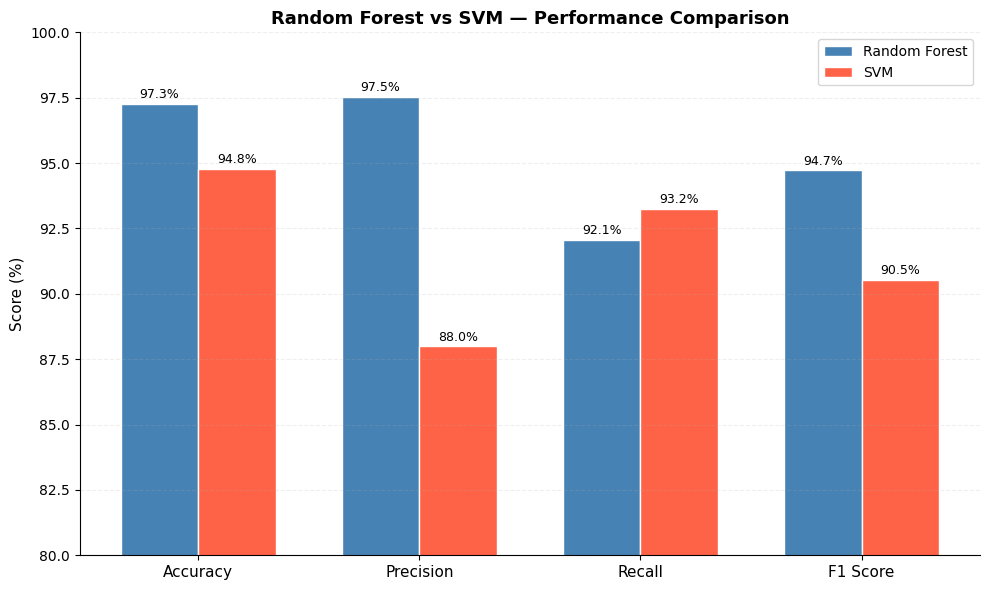

In [10]:
# Collect all metrics for both models
models = ['Random Forest', 'SVM']

metrics = {
    'Accuracy':  [rf_accuracy*100,  svm_accuracy*100],
    'Precision': [rf_precision*100, svm_precision*100],
    'Recall':    [rf_recall*100,    svm_recall*100],
    'F1 Score':  [rf_f1*100,        svm_f1*100]
}

# Print comparison table
print("Model Comparison:")
print(f"{'Metric':<12} {'Random Forest':>15} {'SVM':>10} {'Winner':>10}")
print("─" * 50)
for metric, values in metrics.items():
    winner = "RF" if values[0] > values[1] else "SVM"
    print(f"{metric:<12} {values[0]:>14.2f}% {values[1]:>9.2f}% {winner:>10}")

# Plot comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()],
               width, label='Random Forest',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()],
               width, label='SVM',
               color='tomato', edgecolor='white')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Random Forest vs SVM — Performance Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=11)
ax.set_ylim(80, 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--', axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Model selection — Random Forest chosen

Random Forest outperforms SVM on 3 out of 4 metrics:
- Accuracy:  97.26% vs 94.79%  (+2.47% better)
- Precision: 97.52% vs 87.98%  (+9.54% better)
- F1 Score:  94.72% vs 90.54%  (+4.18% better)

SVM achieves slightly better Recall (93.24% vs 92.07%)
meaning it catches slightly more abnormal beats. However
the difference is only 1.17% while Random Forest's precision
advantage of 9.54% is far more significant.

Random Forest is selected as the final model for deployment
in the Streamlit application in Phase 6.

### Feature importance
Random Forest provides built-in feature importance scores showing
how much each feature contributed to classification decisions
across all 100 trees. Higher scores indicate features the model
relied on more heavily. This validates the EDA findings from
Phase 3 and provides a preview of the SHAP analysis in Phase 5.

Feature Importance Ranking:
Rank   Feature                Importance Bar
────────────────────────────────────────────────────────────
1      kurtosis                  0.1486  █████████████████████████████
2      skewness                  0.1307  ██████████████████████████
3      qrs_width                 0.1240  ████████████████████████
4      rr_interval               0.1121  ██████████████████████
5      std                       0.1023  ████████████████████
6      half_difference           0.0719  ██████████████
7      range                     0.0608  ████████████
8      r_peak_amplitude          0.0533  ██████████
9      min                       0.0527  ██████████
10     max                       0.0516  ██████████
11     mean_second_half          0.0335  ██████
12     mean                      0.0296  █████
13     mean_first_half           0.0290  █████


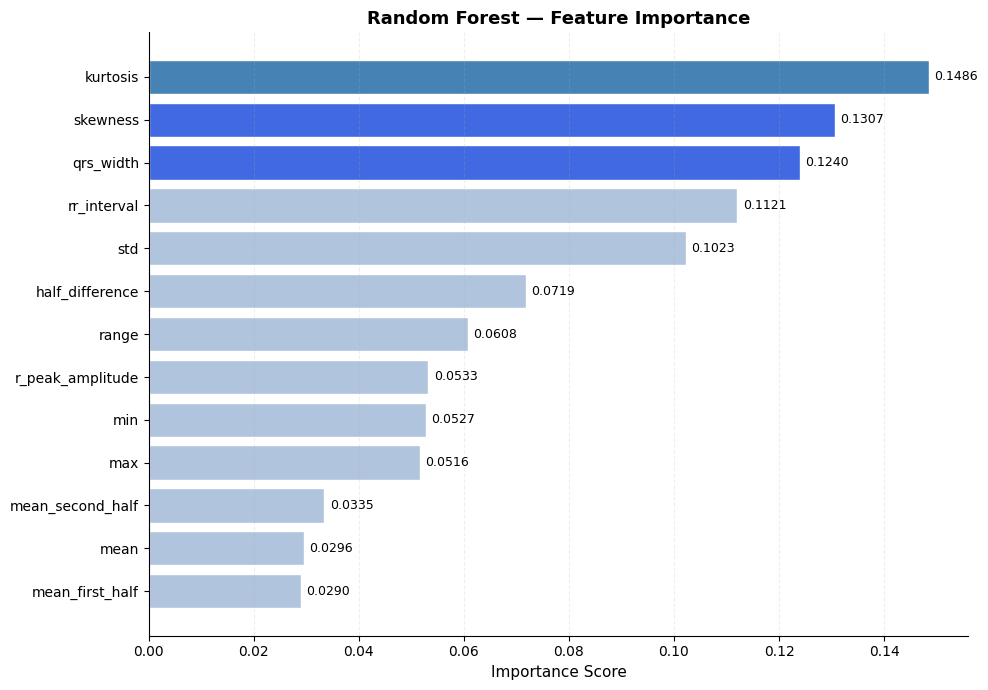

In [12]:
# Get feature importance scores from trained Random Forest
feature_names = list(X.columns)
importances = rf_model.feature_importances_

# Sort features by importance (highest first)
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Print importance scores
print("Feature Importance Ranking:")
print(f"{'Rank':<6} {'Feature':<20} {'Importance':>12} {'Bar'}")
print("─" * 60)
for rank, (feat, imp) in enumerate(zip(sorted_features, sorted_importances), 1):
    bar = "█" * int(imp * 200)
    print(f"{rank:<6} {feat:<20} {imp:>11.4f}  {bar}")

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['steelblue' if i == 0 else
          'royalblue' if i < 3 else
          'lightsteelblue' for i in range(len(sorted_features))]

bars = ax.barh(range(len(sorted_features)),
               sorted_importances,
               color=colors, edgecolor='white')

# Add value labels
for bar, imp in zip(bars, sorted_importances):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}',
            va='center', fontsize=9)

ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features, fontsize=10)
ax.set_title('Random Forest — Feature Importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.invert_yaxis()
ax.grid(True, alpha=0.2, linestyle='--', axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Feature importance observations

Kurtosis confirmed as the most important feature (0.1486),
consistent with EDA findings where it showed the largest
difference between Normal and Abnormal beats (9.034).

Skewness ranked second (0.1307), also consistent with EDA.

Two surprising findings:
- QRS width ranked third (0.1240) despite showing the smallest
  average difference in EDA: demonstrating that features can
  be more powerful in combination than individual analysis suggests
- RR interval ranked fourth (0.1121) despite its unexpected
  direction in EDA : the model learned patterns from rhythm
  that simple average comparison could not capture

The top 5 features (kurtosis, skewness, qrs_width, rr_interval,
std) account for 61.8% of all classification decisions.

Mean-based features (mean, mean_first_half, mean_second_half)
ranked lowest — consistent with their small differences in EDA.

These findings will be further explored and confirmed through
SHAP analysis in Phase 5.

### Saving the trained model
The trained Random Forest model, feature scaler and feature names
are saved to disk so Phase 5 and Phase 6 can load them directly
without retraining. joblib is used for efficient saving of
scikit-learn models.

In [14]:
# Create a models folder to store saved models
models_path = '../models'
os.makedirs(models_path, exist_ok=True)

# Save the Random Forest model
rf_model_path = os.path.join(models_path, 'random_forest_model.pkl')
joblib.dump(rf_model, rf_model_path)
print(f"Random Forest model saved")

# Save the StandardScaler
scaler_path = os.path.join(models_path, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved")

# Save feature names as a text file
feature_names_path = os.path.join(models_path, 'feature_names.txt')
with open(feature_names_path, 'w') as f:
    for name in feature_names:
        f.write(name + '\n')
print(f"Feature names saved")

# Save model performance summary
summary_path = os.path.join(models_path, 'model_summary.txt')
with open(summary_path, 'w') as f:
    f.write("ECG Heartbeat Classification — Model Summary\n")
    f.write("=" * 50 + "\n\n")
    f.write("Best Model: Random Forest\n\n")
    f.write("Performance on 20,477 test beats:\n")
    f.write(f"  Accuracy:  {rf_accuracy*100:.2f}%\n")
    f.write(f"  Precision: {rf_precision*100:.2f}%\n")
    f.write(f"  Recall:    {rf_recall*100:.2f}%\n")
    f.write(f"  F1 Score:  {rf_f1*100:.2f}%\n\n")
    f.write("Training details:\n")
    f.write(f"  Training beats: 81,905\n")
    f.write(f"  Test beats:     20,477\n")
    f.write(f"  n_estimators:   100\n")
    f.write(f"  class_weight:   balanced\n")
print(f"Model summary saved")

# Verify all files saved correctly
print(f"\nFiles saved in {models_path}/:")
for f in os.listdir(models_path):
    size = os.path.getsize(os.path.join(models_path, f))
    print(f"  {f:<35} {size:>10,} bytes")

# Quick verification — reload and test model
print(f"\nVerification — reloading model and testing...")
loaded_model = joblib.load(rf_model_path)
test_pred = loaded_model.predict(X_test[:5])
actual = y_test.values[:5]
print(f"  First 5 predictions: {test_pred}")
print(f"  Actual labels:       {actual}")
print(f"  Match: {all(test_pred == actual)}")

Random Forest model saved
Scaler saved
Feature names saved
Model summary saved

Files saved in ../models/:
  scaler.pkl                               1,311 bytes
  random_forest_model.pkl             50,684,121 bytes
  model_summary.txt                          358 bytes
  feature_names.txt                          129 bytes

Verification — reloading model and testing...
  First 5 predictions: [0 0 0 0 0]
  Actual labels:       [0 0 0 0 0]
  Match: True


## Phase 4 Summary — ML Model Training

### Models trained
Two classifiers were trained on 81,905 heartbeat segments
and evaluated on 20,477 unseen test beats.

### Results

Random Forest:
- Accuracy:  97.26%
- Precision: 97.52%
- Recall:    92.07%
- F1 Score:  94.72%

SVM:
- Accuracy:  94.79%
- Precision: 87.98%
- Recall:    93.24%
- F1 Score:  90.54%

### Model selected
Random Forest selected as the final model — outperforms SVM
on 3 out of 4 metrics with significantly stronger overall
performance. SVM achieved marginally better recall (93.24%
vs 92.07%) but Random Forest wins on all other metrics.

### Feature importance
Kurtosis confirmed as most important feature (0.1486)
consistent with EDA findings in Phase 3. Top 5 features
account for 61.8% of all classification decisions.

### Files saved
- models/random_forest_model.pkl
- models/scaler.pkl
- models/feature_names.txt
- models/model_summary.txt

### Next step
Phase 5 — Explainable AI using SHAP and LIME to explain
model predictions in clinically meaningful terms.